# GitHub Activity Analysis

Fetches commit, PR, and issue data across repos via the `gh` CLI and saves them as CSVs.  
Run the fetch cells once, then iterate on the analysis cells freely.

**Prerequisites:** `gh auth login` must already be done in your shell.

In [1]:
import subprocess
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

In [2]:
import os, re

def gh_api(endpoint, paginate=True):
    """Call gh REST api, return parsed JSON."""
    env = {**os.environ, 'NO_COLOR': '1', 'GH_PAGER': '', 'CLICOLOR': '0'}
    cmd = ['gh', 'api'] + (['--paginate'] if paginate else []) + [endpoint]
    result = subprocess.run(cmd, capture_output=True, text=True, env=env)
    if result.returncode != 0:
        print(f'  Warning: {endpoint} → {result.stderr.strip()[:120]}')
        return []
    text = re.sub(r'\x1b\[[0-9;]*[mKHJ]', '', result.stdout).strip()
    if text.startswith('[') and '][' in text:
        text = '[' + text[1:-1].replace('][', ',') + ']'
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        print(f'  JSON parse error for {endpoint}: {repr(text[:120])}')
        return []

def gh_graphql(query, **variables):
    """Execute a GraphQL query via JSON stdin body, return the data dict."""
    env = {**os.environ, 'NO_COLOR': '1', 'GH_PAGER': '', 'CLICOLOR': '0'}
    body = json.dumps({'query': query, 'variables': variables})
    result = subprocess.run(
        ['gh', 'api', 'graphql', '--input', '-'],
        input=body, capture_output=True, text=True, env=env
    )
    if result.returncode != 0:
        print(f'  GraphQL error: {result.stderr.strip()[:200]}')
        return {}
    text = re.sub(r'\x1b\[[0-9;]*[mKHJ]', '', result.stdout).strip()
    try:
        return json.loads(text).get('data', {})
    except json.JSONDecodeError:
        print(f'  JSON parse error: {repr(text[:120])}')
        return {}

def graphql_to_df(outer_query, inner_query, get_connection, get_more_conn, to_row,
                  include_forks=False, allowed_owners=None):
    """
    Paginate viewer.repositories via GraphQL and collect rows into a DataFrame.

    outer_query    — fetches viewer.login + paginated viewer.repositories, each node
                     containing an inner connection (commits / PRs / issues)
    inner_query    — follow-up query for repos whose inner connection has >100 items;
                     receives $owner, $name, $cursor
    get_connection — repo_node  -> inner connection dict {nodes, pageInfo}
    get_more_conn  — data       -> inner connection dict from the follow-up query
    to_row         — (item, slug) -> dict for one DataFrame row
    allowed_owners — set of GitHub logins (user + owned orgs) to include; None = all

    Returns (df, repo_slugs, my_login).
    """
    rows, slugs = [], []
    my_login = ''
    repo_cursor = None

    while True:
        data = gh_graphql(outer_query, cursor=repo_cursor)
        viewer = data.get('viewer', {})
        if not my_login:
            my_login = viewer.get('login', '')

        repos_conn = viewer.get('repositories', {})
        for repo in repos_conn.get('nodes', []):
            if repo.get('isFork') and not include_forks:
                continue
            slug = repo['nameWithOwner']
            if allowed_owners and slug.split('/')[0] not in allowed_owners:
                continue
            if slug not in slugs:
                slugs.append(slug)

            conn = get_connection(repo) or {}
            for item in conn.get('nodes', []):
                rows.append(to_row(item, slug))

            pi = conn.get('pageInfo', {})
            inner_cursor = pi.get('endCursor') if pi.get('hasNextPage') else None
            while inner_cursor:
                owner, name = slug.split('/')
                more = gh_graphql(inner_query, owner=owner, name=name, cursor=inner_cursor)
                more_conn = get_more_conn(more) or {}
                for item in more_conn.get('nodes', []):
                    rows.append(to_row(item, slug))
                pi = more_conn.get('pageInfo', {})
                inner_cursor = pi.get('endCursor') if pi.get('hasNextPage') else None

        if not repos_conn.get('pageInfo', {}).get('hasNextPage'):
            break
        repo_cursor = repos_conn['pageInfo']['endCursor']

    return pd.DataFrame(rows), slugs, my_login

In [3]:
INCLUDE_FORKS = False  # set True to include forked repos

# Shared fragment for the outer repo loop (same for all three queries)
_REPOS_OUTER = """
  viewer {
    login
    repositories(
      first: 100
      after: $cursor
      ownerAffiliations: [OWNER, ORGANIZATION_MEMBER]
      privacy: PUBLIC
      orderBy: {field: PUSHED_AT, direction: DESC}
    ) {
      pageInfo { hasNextPage endCursor }
      nodes {
        nameWithOwner
        isFork
        %s
      }
    }
  }
"""

COMMITS_OUTER = ("query($cursor: String) {" + _REPOS_OUTER + "}") % """
        defaultBranchRef {
          target {
            ... on Commit {
              history(first: 100) {
                pageInfo { hasNextPage endCursor }
                nodes { oid message committedDate author { name } }
              }
            }
          }
        }"""

COMMITS_MORE = """
query($owner: String!, $name: String!, $cursor: String!) {
  repository(owner: $owner, name: $name) {
    defaultBranchRef { target { ... on Commit {
      history(first: 100, after: $cursor) {
        pageInfo { hasNextPage endCursor }
        nodes { oid message committedDate author { name } }
      }
    } } }
  }
}"""

PRS_OUTER = ("query($cursor: String) {" + _REPOS_OUTER + "}") % """
        pullRequests(first: 100, states: [OPEN, CLOSED, MERGED], orderBy: {field: CREATED_AT, direction: DESC}) {
          pageInfo { hasNextPage endCursor }
          nodes { number title state createdAt closedAt mergedAt isDraft body }
        }"""

PRS_MORE = """
query($owner: String!, $name: String!, $cursor: String!) {
  repository(owner: $owner, name: $name) {
    pullRequests(first: 100, after: $cursor, states: [OPEN, CLOSED, MERGED]) {
      pageInfo { hasNextPage endCursor }
      nodes { number title state createdAt closedAt mergedAt isDraft body }
    }
  }
}"""

ISSUES_OUTER = ("query($cursor: String) {" + _REPOS_OUTER + "}") % """
        issues(first: 100, states: [OPEN, CLOSED], orderBy: {field: CREATED_AT, direction: DESC}) {
          pageInfo { hasNextPage endCursor }
          nodes { number title state createdAt closedAt author { login } comments { totalCount } }
        }"""

ISSUES_MORE = """
query($owner: String!, $name: String!, $cursor: String!) {
  repository(owner: $owner, name: $name) {
    issues(first: 100, after: $cursor, states: [OPEN, CLOSED]) {
      pageInfo { hasNextPage endCursor }
      nodes { number title state createdAt closedAt author { login } comments { totalCount } }
    }
  }
}"""

## Fetch data

Commits use the GraphQL API (all repos + their history in one paginated query). PRs and issues use the REST API per repo."

In [4]:
# Fetch viewer login + orgs where viewer is an owner (admin role)
_identity = gh_graphql("""
query {
  viewer {
    login
    organizations(first: 100) {
      nodes { login viewerCanAdminister }
    }
  }
}
""")
my_login = _identity.get('viewer', {}).get('login', '')
_orgs = _identity.get('viewer', {}).get('organizations', {}).get('nodes', [])
owned_org_logins = {o['login'] for o in _orgs if o.get('viewerCanAdminister')}
ALLOWED_OWNERS = {my_login} | owned_org_logins

print(f'Login:      {my_login}')
print(f'Owned orgs: {owned_org_logins}')
print(f'Filtering to owners: {ALLOWED_OWNERS}')

Login:      thenomadlad
Owned orgs: {'indusbiomed', 'caramlops', 'retrofit-ui', 'NorrisGang'}
Filtering to owners: {'indusbiomed', 'caramlops', 'NorrisGang', 'thenomadlad', 'retrofit-ui'}


In [5]:
# ── Commits ──────────────────────────────────────────────────────────────────
def commit_row(item, slug):
    msg = item.get('message', '') or ''
    return {
        'repo': slug.split('/')[-1], 'slug': slug,
        'sha': item.get('oid', '')[:8],
        'date': item.get('committedDate', ''),
        'author': (item.get('author') or {}).get('name', ''),
        'message': msg.split('\n')[0][:120],
        'claude_coauthored': 'co-authored-by: claude' in msg.lower(),
        'is_merge': msg.startswith('Merge '),
    }

commits_df, repo_slugs, my_login = graphql_to_df(
    COMMITS_OUTER, COMMITS_MORE,
    get_connection=lambda r: (r.get('defaultBranchRef') or {}).get('target', {}).get('history'),
    get_more_conn=lambda d: d.get('repository', {}).get('defaultBranchRef', {}).get('target', {}).get('history'),
    to_row=commit_row,
    include_forks=INCLUDE_FORKS,
    allowed_owners=ALLOWED_OWNERS,
)
commits_df['date'] = pd.to_datetime(commits_df['date'], utc=True)
commits_df['year'] = commits_df['date'].dt.year
commits_df['month'] = commits_df['date'].dt.to_period('M')
commits_df.to_csv(DATA_DIR / 'commits.csv', index=False)
print(f'{len(commits_df)} commits across {len(repo_slugs)} repos')
commits_df.head()

641 commits across 36 repos


/tmp/ipykernel_353394/1187673778.py:24: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  commits_df['month'] = commits_df['date'].dt.to_period('M')


,repo,slug,sha,date,author,message,claude_coauthored,is_merge,year,month
0,adityadharacom,thenomadlad/adityadharacom,fc7dd778,2026-06-15 07:38:13+00:00,Aditya Dhara,Merge pull request #32 from thenomadlad/move_t...,False,True,2026,2026-06
1,adityadharacom,thenomadlad/adityadharacom,0a1d69a5,2026-06-15 07:34:07+00:00,Someone Somewhere,"CI: drop Playwright e2e, run build instead",True,False,2026,2026-06
2,adityadharacom,thenomadlad/adityadharacom,e5c532cf,2026-06-15 07:26:00+00:00,Someone Somewhere,CI: add 20m timeout and cache Playwright browsers,True,False,2026,2026-06
3,adityadharacom,thenomadlad/adityadharacom,8e9399ed,2026-06-14 22:32:56+00:00,Someone Somewhere,Upgrade CI to Node 26 + pnpm 11 via corepack,True,False,2026,2026-06
4,adityadharacom,thenomadlad/adityadharacom,57d1572c,2026-06-14 22:08:13+00:00,Someone Somewhere,Working and updated,False,False,2026,2026-06


In [6]:
# ── Pull Requests ─────────────────────────────────────────────────────────────
def pr_row(item, slug):
    body = item.get('body', '') or ''
    return {
        'repo': slug.split('/')[-1], 'slug': slug,
        'number': item.get('number'),
        'title': (item.get('title', '') or '')[:120],
        'state': (item.get('state', '') or '').lower(),
        'created_at': item.get('createdAt', ''),
        'closed_at': item.get('closedAt', ''),
        'merged_at': item.get('mergedAt', ''),
        'draft': item.get('isDraft', False),
        'body_length': len(body),
        'claude_mentioned': 'claude' in body.lower(),
    }

prs_df, _, _ = graphql_to_df(
    PRS_OUTER, PRS_MORE,
    get_connection=lambda r: r.get('pullRequests'),
    get_more_conn=lambda d: d.get('repository', {}).get('pullRequests'),
    to_row=pr_row,
    include_forks=INCLUDE_FORKS,
    allowed_owners=ALLOWED_OWNERS,
)
for col in ['created_at', 'closed_at', 'merged_at']:
    prs_df[col] = pd.to_datetime(prs_df[col], utc=True)
prs_df['time_to_merge_days'] = (
    (prs_df['merged_at'] - prs_df['created_at']).dt.total_seconds() / 86400
)
prs_df.to_csv(DATA_DIR / 'prs.csv', index=False)
print(f'{len(prs_df)} PRs')
prs_df.head()

100 PRs


,repo,slug,number,title,state,created_at,closed_at,merged_at,draft,body_length,claude_mentioned,time_to_merge_days
0,adityadharacom,thenomadlad/adityadharacom,32,Working and updated,merged,2026-06-14 22:08:50+00:00,2026-06-15 07:38:14+00:00,2026-06-15 07:38:14+00:00,False,0,False,0.395417
1,adityadharacom,thenomadlad/adityadharacom,30,Removed tag build condition,merged,2026-03-17 08:39:02+00:00,2026-03-17 08:42:10+00:00,2026-03-17 08:42:10+00:00,False,0,False,0.002176
2,adityadharacom,thenomadlad/adityadharacom,29,Removed mermaid and moved to netlify,merged,2026-03-17 08:15:04+00:00,2026-03-17 08:35:53+00:00,2026-03-17 08:35:52+00:00,False,0,False,0.014444
3,adityadharacom,thenomadlad/adityadharacom,28,Update deploy strategy,merged,2026-03-17 07:06:14+00:00,2026-03-17 07:10:42+00:00,2026-03-17 07:10:42+00:00,False,0,False,0.003102
4,adityadharacom,thenomadlad/adityadharacom,27,Move to solid,merged,2026-03-13 18:41:02+00:00,2026-03-17 06:37:58+00:00,2026-03-17 06:37:58+00:00,False,0,False,3.497870


In [7]:
# ── Issues ────────────────────────────────────────────────────────────────────
my_logins = {my_login}

def issue_row(item, slug):
    author = (item.get('author') or {}).get('login', '')
    return {
        'repo': slug.split('/')[-1], 'slug': slug,
        'number': item.get('number'),
        'title': (item.get('title', '') or '')[:120],
        'state': (item.get('state', '') or '').lower(),
        'created_at': item.get('createdAt', ''),
        'closed_at': item.get('closedAt', ''),
        'author': author,
        'comments': (item.get('comments') or {}).get('totalCount', 0),
        'is_mine': author in my_logins,
    }

issues_df, _, _ = graphql_to_df(
    ISSUES_OUTER, ISSUES_MORE,
    get_connection=lambda r: r.get('issues'),
    get_more_conn=lambda d: d.get('repository', {}).get('issues'),
    to_row=issue_row,
    include_forks=INCLUDE_FORKS,
    allowed_owners=ALLOWED_OWNERS,
)
for col in ['created_at', 'closed_at']:
    issues_df[col] = pd.to_datetime(issues_df[col], utc=True)
issues_df.to_csv(DATA_DIR / 'issues.csv', index=False)
print(f'{len(issues_df)} issues')
issues_df.head()

64 issues


,repo,slug,number,title,state,created_at,closed_at,author,comments,is_mine
0,adityadharacom,thenomadlad/adityadharacom,31,HOTW: obsidian alternative,open,2026-05-05 09:06:35+00:00,NaT,thenomadlad,0,True
1,adityadharacom,thenomadlad/adityadharacom,25,Revamp design,closed,2025-11-29 07:30:45+00:00,2025-12-28 09:04:48+00:00,thenomadlad,0,True
2,adityadharacom,thenomadlad/adityadharacom,24,Upgrade astro,closed,2025-11-29 07:29:52+00:00,2025-11-29 08:13:23+00:00,thenomadlad,0,True
3,adityadharacom,thenomadlad/adityadharacom,22,Use llms to generate blogs,open,2025-10-15 19:43:48+00:00,NaT,thenomadlad,0,True
4,retrofit-ui,retrofit-ui/retrofit-ui,93,"feat: datetime, date, and time picker field types",closed,2026-06-14 10:28:57+00:00,2026-06-14 20:54:45+00:00,thenomadlad,0,True


---
## Analysis

Reload from CSV if you just want to re-run charts without re-fetching:

In [8]:
# Reload from CSV (run this cell instead of the fetch cells if data already exists)
commits_df = pd.read_csv(DATA_DIR / 'commits.csv', parse_dates=['date'])
commits_df['date'] = pd.to_datetime(commits_df['date'], utc=True)
commits_df['month'] = pd.to_datetime(commits_df['date']).dt.to_period('M')
commits_df['year'] = commits_df['date'].dt.year

prs_df = pd.read_csv(DATA_DIR / 'prs.csv', parse_dates=['created_at', 'closed_at', 'merged_at'])
issues_df = pd.read_csv(DATA_DIR / 'issues.csv', parse_dates=['created_at', 'closed_at'])

print(f'commits: {len(commits_df)} | prs: {len(prs_df)} | issues: {len(issues_df)}')

commits: 641 | prs: 100 | issues: 64


/tmp/ipykernel_353394/1565345695.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  commits_df['month'] = pd.to_datetime(commits_df['date']).dt.to_period('M')


### Commit activity over time

/tmp/ipykernel_353394/1837125913.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(commits_df['date'].dt.to_period('M'))


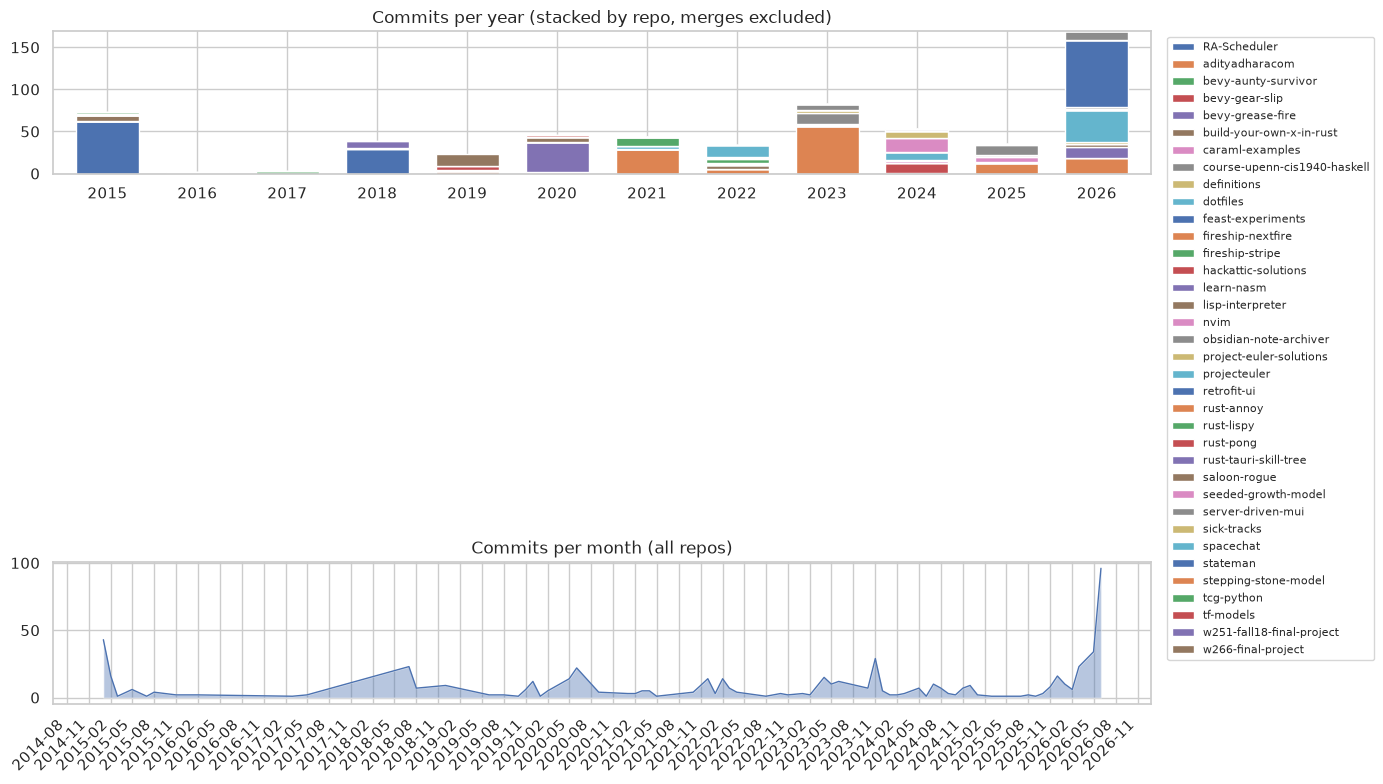

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: commits per year, stacked by repo
by_year_repo = (
    commits_df[~commits_df['is_merge']]
    .groupby(['year', 'repo'])
    .size()
    .unstack(fill_value=0)
)
by_year_repo.plot(kind='bar', stacked=True, ax=axes[0], width=0.7)
axes[0].set_title('Commits per year (stacked by repo, merges excluded)')
axes[0].set_xlabel('')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# Bottom: commits per month (rolling activity)
monthly = (
    commits_df[~commits_df['is_merge']]
    .groupby(commits_df['date'].dt.to_period('M'))
    .size()
    .rename('commits')
)
monthly.index = monthly.index.to_timestamp()
axes[1].fill_between(monthly.index, monthly.values, alpha=0.4)
axes[1].plot(monthly.index, monthly.values, linewidth=1)
axes[1].set_title('Commits per month (all repos)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(DATA_DIR / 'commits_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

### AI co-authorship

In [10]:
ai = commits_df[commits_df['claude_coauthored'] & ~commits_df['is_merge']]
total = commits_df[~commits_df['is_merge']]

print(f'Total non-merge commits: {len(total)}')
print(f'Claude co-authored (tagged): {len(ai)}')
print(f'Percentage tagged: {len(ai)/len(total)*100:.1f}%')
print()
print('Claude-tagged commits:')
print(ai[['repo', 'date', 'message']].to_string(index=False))

Total non-merge commits: 604
Claude co-authored (tagged): 43
Percentage tagged: 7.1%

Claude-tagged commits:
                  repo                      date                                                                                      message
        adityadharacom 2026-06-15 07:34:07+00:00                                                   CI: drop Playwright e2e, run build instead
        adityadharacom 2026-06-15 07:26:00+00:00                                            CI: add 20m timeout and cache Playwright browsers
        adityadharacom 2026-06-14 22:32:56+00:00                                                 Upgrade CI to Node 26 + pnpm 11 via corepack
           retrofit-ui 2026-06-14 20:54:44+00:00                               feat: feat: datetime, date, and time picker field types (#102)
           retrofit-ui 2026-06-14 20:54:16+00:00                          feat: Calendar view for event/scheduling data (CalendarSpec) (#101)
           retrofit-ui 2026-06-14 20:41

/tmp/ipykernel_353394/1206965494.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_all = total.groupby(total['date'].dt.to_period('M')).size()
/tmp/ipykernel_353394/1206965494.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_ai = ai.groupby(ai['date'].dt.to_period('M')).size()


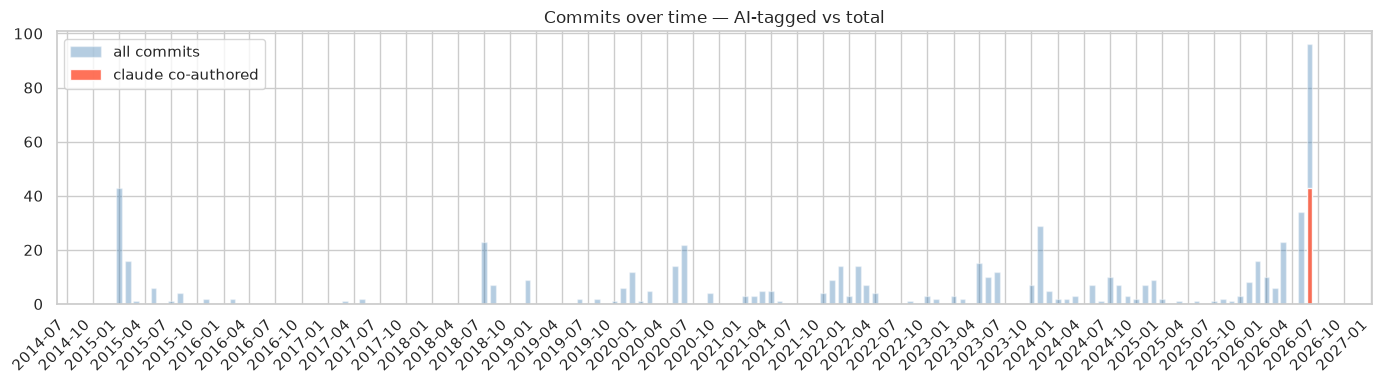

In [11]:
# When did AI tagging start? Plot tagged commits on the timeline
fig, ax = plt.subplots(figsize=(14, 4))

monthly_all = total.groupby(total['date'].dt.to_period('M')).size()
monthly_all.index = monthly_all.index.to_timestamp()
ax.bar(monthly_all.index, monthly_all.values, width=20, alpha=0.4, label='all commits', color='steelblue')

if len(ai) > 0:
    monthly_ai = ai.groupby(ai['date'].dt.to_period('M')).size()
    monthly_ai.index = monthly_ai.index.to_timestamp()
    ax.bar(monthly_ai.index, monthly_ai.values, width=20, alpha=0.9, label='claude co-authored', color='tomato')

ax.set_title('Commits over time — AI-tagged vs total')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'ai_tagged.png', dpi=150, bbox_inches='tight')
plt.show()

### PR velocity

/tmp/ipykernel_353394/4065335643.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_month = merged.groupby(merged['merged_at'].dt.to_period('M')).size()


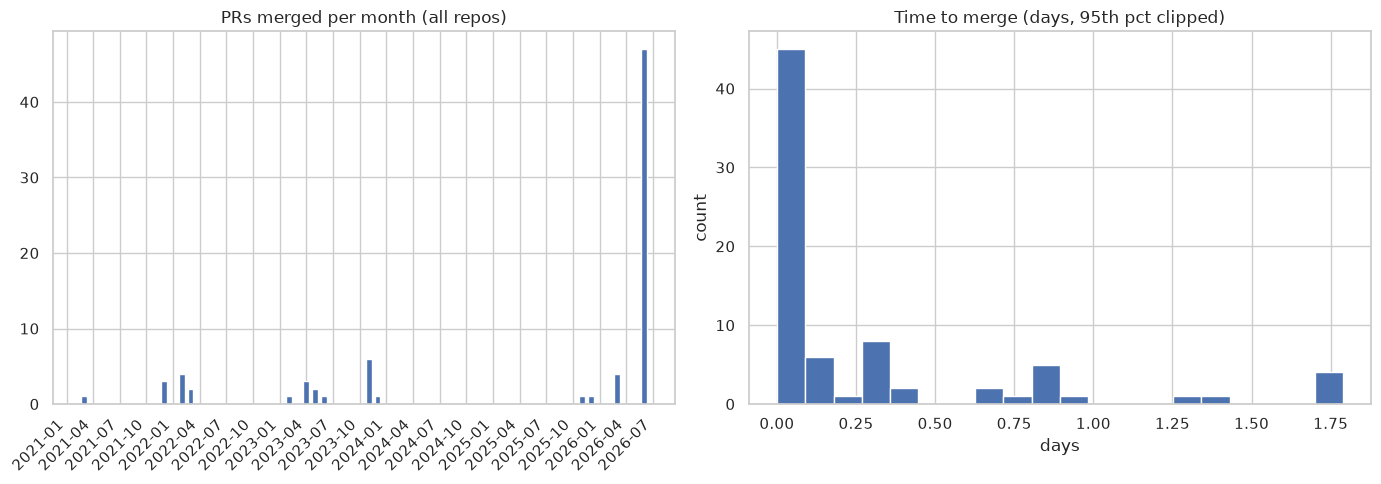

Median time to merge: 0.0 days
Same-day merges (<1 day): 71 of 77


In [12]:
merged = prs_df[prs_df['merged_at'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PRs merged per month
by_month = merged.groupby(merged['merged_at'].dt.to_period('M')).size()
by_month.index = by_month.index.to_timestamp()
axes[0].bar(by_month.index, by_month.values, width=20)
axes[0].set_title('PRs merged per month (all repos)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Time to merge distribution
ttm = merged['time_to_merge_days'].dropna()
ttm_clipped = ttm.clip(upper=ttm.quantile(0.95))  # clip outliers for readability
axes[1].hist(ttm_clipped, bins=20, edgecolor='white')
axes[1].set_title('Time to merge (days, 95th pct clipped)')
axes[1].set_xlabel('days')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.savefig(DATA_DIR / 'pr_velocity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Median time to merge: {ttm.median():.1f} days')
print(f'Same-day merges (<1 day): {(ttm < 1).sum()} of {len(ttm)}')

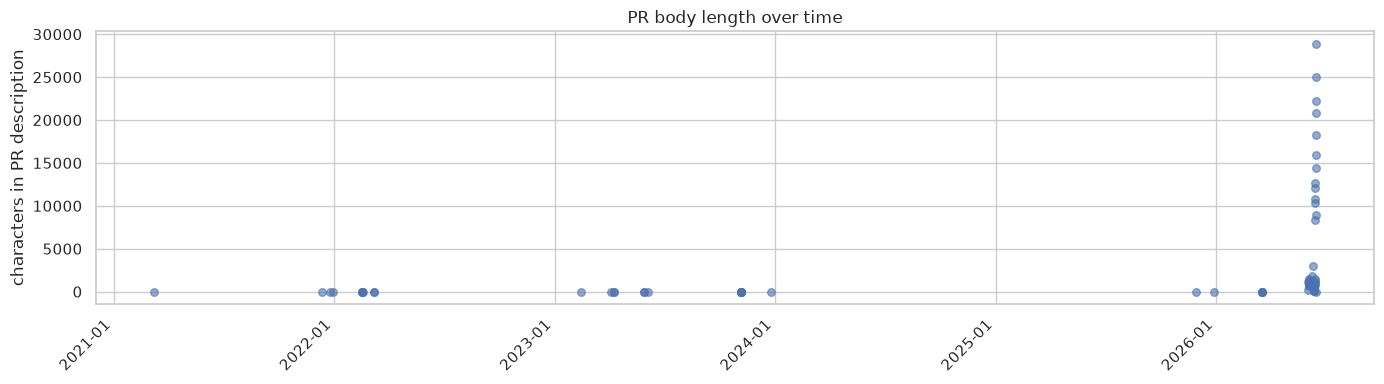

In [13]:
# PR description length over time — does writing improve / get lazier?
merged_sorted = merged.sort_values('merged_at')

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(merged_sorted['merged_at'], merged_sorted['body_length'], alpha=0.6, s=30)
ax.set_title('PR body length over time')
ax.set_ylabel('characters in PR description')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Issues — backlog health

/tmp/ipykernel_353394/2696516872.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_month = issues_df.groupby(issues_df['created_at'].dt.to_period('M')).size()


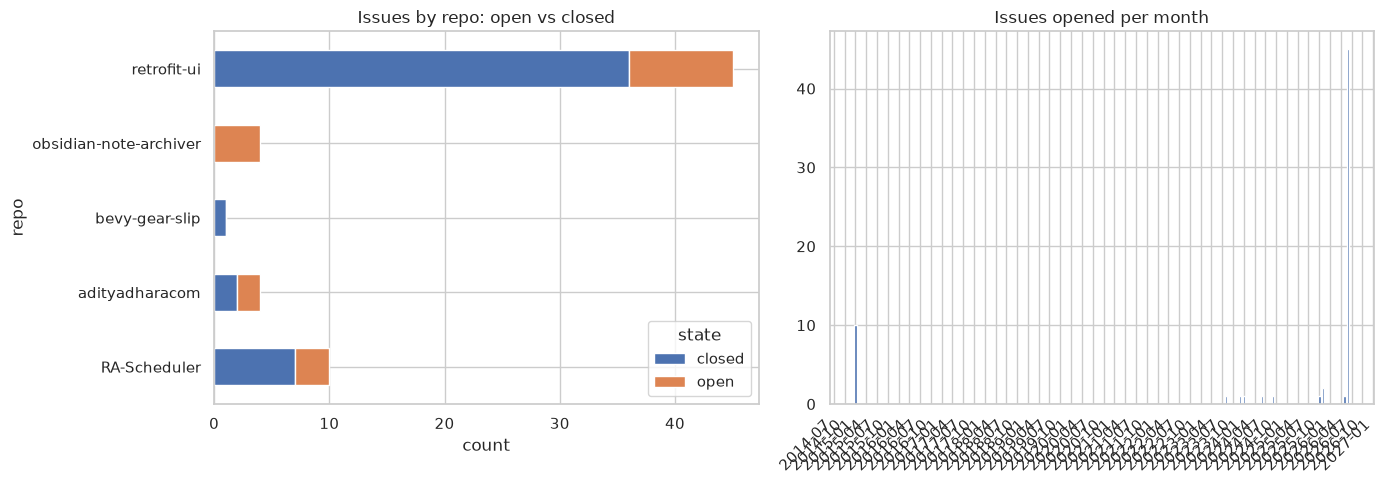

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Open vs closed by repo
issue_state = issues_df.groupby(['repo', 'state']).size().unstack(fill_value=0)
issue_state.plot(kind='barh', stacked=True, ax=axes[0])
axes[0].set_title('Issues by repo: open vs closed')
axes[0].set_xlabel('count')

# Issues opened per month
by_month = issues_df.groupby(issues_df['created_at'].dt.to_period('M')).size()
by_month.index = by_month.index.to_timestamp()
axes[1].bar(by_month.index, by_month.values, width=20)
axes[1].set_title('Issues opened per month')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(DATA_DIR / 'issues.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# External contributions — issues opened by others (not you)
external = issues_df[~issues_df['is_mine'] & issues_df['is_mine'].notna()]
print('Issues filed by external contributors:')
print(external[['repo', 'created_at', 'state', 'author', 'title']].to_string(index=False))

Issues filed by external contributors:
                  repo                created_at  state           author                                                                 title
obsidian-note-archiver 2024-06-21 15:16:55+00:00   open   connradolisboa                           Button to return note to original location.
obsidian-note-archiver 2024-01-05 04:37:29+00:00   open            neins                             Archive under heading / select to archive
obsidian-note-archiver 2023-12-17 18:43:47+00:00   open skullbunnygalaxy Allow config option of turning off copying folder path when archiving
obsidian-note-archiver 2023-08-14 05:45:29+00:00   open           jeff-h                                         Archive by note creation date
          RA-Scheduler 2015-01-29 21:43:44+00:00 closed           gbrova                   Menu bar positions should highlight the active page
          RA-Scheduler 2015-01-29 20:06:31+00:00   open           gbrova                               

### Commit message patterns

Quick look at vocabulary — what words come up most in commit messages?

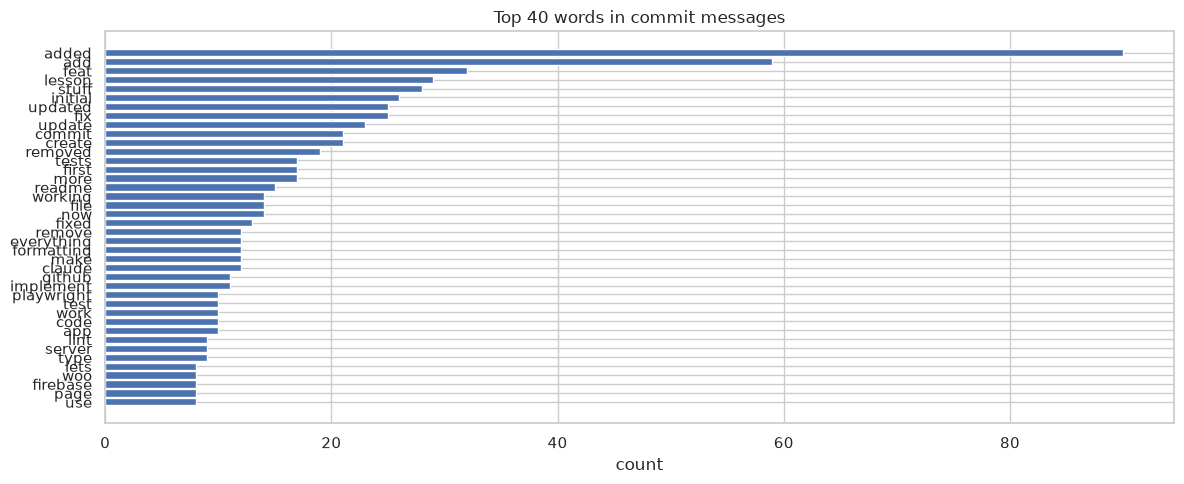

In [16]:
from collections import Counter
import re

STOPWORDS = {
    'and', 'the', 'to', 'a', 'of', 'in', 'for', 'is', 'it', 'this',
    'with', 'on', 'that', 'from', 'up', 'some', 'was', 'be', 'are',
    'all', 'not', 'as', 'an', 'or', 'at', 'by', 'we', 'have', 'merge',
    'pull', 'request', 'branch', 'into', 'main',
}

words = Counter()
for msg in commits_df[~commits_df['is_merge']]['message']:
    tokens = re.findall(r'[a-z]+', str(msg).lower())
    words.update(t for t in tokens if t not in STOPWORDS and len(t) > 2)

top = words.most_common(40)
fig, ax = plt.subplots(figsize=(12, 5))
labels, counts = zip(*top)
ax.barh(labels[::-1], counts[::-1])
ax.set_title('Top 40 words in commit messages')
ax.set_xlabel('count')
plt.tight_layout()
plt.show()

---
## Scratch space

Add cells here for blog-specific stats or one-off queries.

In [17]:
# Example: which month had the most commits?
commits_df[~commits_df['is_merge']].groupby('month').size().sort_values(ascending=False).head(10)

month
2026-06    96
2015-01    43
2026-05    34
2023-11    29
2018-07    23
2026-03    23
2020-06    22
2025-12    16
2015-02    16
2023-04    15
Freq: M, dtype: int64